In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("../RSF_Dataset.csv")

In [62]:
#Naive baseline, all predictions are overall average
mean_value = y_train.mean()
baseline_preds = [mean_value] * len(y_test)

from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, baseline_preds))

31.650523095325727


In [63]:
df

,timestamp,current_count,capacity,percent_full,weekday,hour,minute,temperature,feels_like,precipitation,humidity
0,2026-03-09 17:33:04,140,150,93.33,0,17,33,61.7,61.9,0.0,76.0
1,2026-03-09 20:22:27,129,150,86.00,0,20,22,66.9,68.2,0.0,62.0
2,2026-03-09 21:52:19,130,150,86.67,0,21,52,69.8,69.9,0.0,54.0
3,2026-03-09 23:34:27,0,150,0.00,0,23,34,68.4,65.3,0.0,54.0
4,2026-03-10 00:26:09,0,150,0.00,1,0,26,68.4,65.3,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...,...
308,2026-03-20 14:46:00,71,150,47.33,4,14,46,85.7,89.7,0.0,43.0
309,2026-03-20 15:16:25,75,150,50.00,4,15,16,86.8,89.3,0.0,39.0
310,2026-03-20 15:49:13,69,150,46.00,4,15,49,86.5,88.0,0.0,38.0
311,2026-03-20 16:18:22,79,150,52.67,4,16,18,85.3,85.8,0.0,38.0


In [64]:
df["open_hour"] = 7
df["close_hour"] = 23

# weekend opening time
df.loc[df["weekday"].isin([5,6]), "open_hour"] = 8

# Saturday closing time
df.loc[df["weekday"] == 5, "close_hour"] = 18

df["is_open"] = (
    (df["hour"] >= df["open_hour"]) &
    (df["hour"] < df["close_hour"])
).astype(int)


In [65]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df["week_of_year"] = df["timestamp"].dt.isocalendar().week.astype(int)

df["is_weekend"] = df["weekday"].isin([5,6]).astype(int)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df = df[df["is_open"] == 1]

In [66]:
df["minutes_until_close"] = (
    (df["close_hour"] - df["hour"]) * 60
    - df["minute"]
)

In [67]:
corr_target = df.corr(numeric_only=True)["percent_full"].sort_values(ascending=False)

print(corr_target)

percent_full           1.000000
current_count          1.000000
hour                   0.389952
hour_cos               0.115732
close_hour             0.102591
temperature           -0.012763
minute                -0.018243
feels_like            -0.038187
humidity              -0.108444
week_of_year          -0.189695
open_hour             -0.234813
is_weekend            -0.234813
minutes_until_close   -0.345447
weekday               -0.350808
hour_sin              -0.441226
capacity                    NaN
precipitation               NaN
is_open                     NaN
month                       NaN
Name: percent_full, dtype: float64


In [68]:
features = [
    "hour_sin",
    "hour_cos",
    "minute",
    "weekday",
    "week_of_year",
    "temperature",
    "feels_like",
    "humidity",
    "minutes_until_close"
]

In [69]:
X = df[features]
y = df["percent_full"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42)


In [71]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
predictions = model.predict(X_test)
mae_test = mean_absolute_error(y_test, predictions)
rmse_test = np.sqrt(mean_squared_error(y_test, predictions))


In [76]:
print("Mean Absolute Error (Testing Data):", mae_test)
print("RMSE (Testing Data):", rmse_test)


Mean Absolute Error (Testing Data): 10.87645708723323
RMSE (Testing Data): 14.184364234767862


In [77]:
predictions_training = model.predict(X_train)
mae_train = mean_absolute_error(y_train, predictions_training)
rmse_train = np.sqrt(mean_squared_error(y_train, predictions_training))
print("Mean Absolute Error (Training Data):", mae_train)
print("RMSE (Training Data):", rmse_train)



Mean Absolute Error (Training Data): 9.708870886540652
RMSE (Training Data): 12.69905939051507


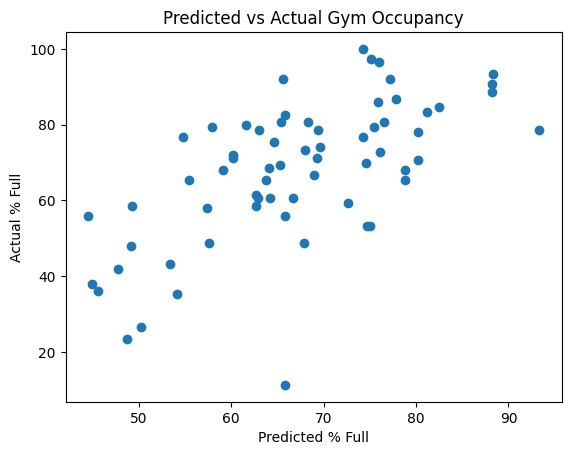

In [79]:
plt.scatter(predictions, y_test)
plt.xlabel("Predicted % Full")
plt.ylabel("Actual % Full")
plt.title("Predicted vs Actual Gym Occupancy")
plt.show()